## Final Project

### Step 1: Setting up project

Uploaded the dataset to data folder in this repoistory

### Step 2: Setting up data

In [76]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt    
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
import time

In [34]:
dataset = pd.read_csv("data/synthetic_clinical_dataset.csv")
print("First 5 rows\n", dataset.head(5))
print("Shape:\n", dataset.shape)
print("Column data types:", dataset.dtypes)
print("Numeric features summary:", dataset.describe())

First 5 rows
    patient_id  age     sex   bmi  systolic_bp  diastolic_bp  glucose  \
0        1001   63    Male  24.1        131.0          81.0    136.2   
1        1002   52    Male  20.8        118.0          91.0    136.5   
2        1003   66    Male  30.0        144.0          73.0    100.0   
3        1004   82    Male  16.8        112.0          76.0    117.3   
4        1005   50  Female  25.4        102.0          65.0    128.0   

   cholesterol  creatinine  diabetes  hypertension      diagnosis  \
0        210.3        1.04         0             0         Sepsis   
1        207.9        1.49         0             1         Normal   
2        179.5        1.15         0             0         Normal   
3        228.3        0.59         0             0  Heart Failure   
4        150.7        1.38         0             0         Normal   

   readmission_30d  mortality  
0                0          0  
1                0          0  
2                0          0  
3         

diagnosis
Normal           5590
Pneumonia        2005
Heart Failure    1763
Sepsis            642
Name: count, dtype: int64


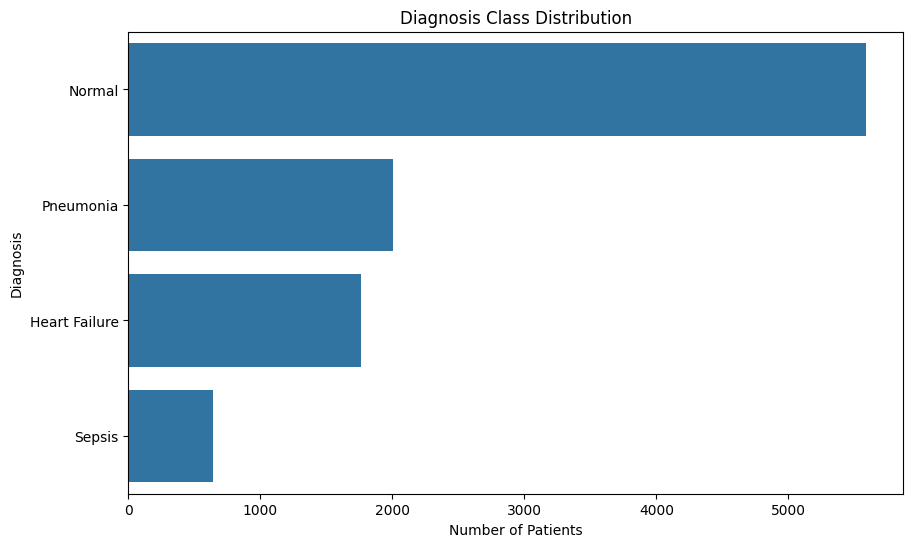

In [31]:
print(dataset['diagnosis'].value_counts())
plt.figure(figsize=(10,6))
sns.countplot(y='diagnosis', data=dataset, order=dataset['diagnosis'].value_counts().index)
plt.title("Diagnosis Class Distribution")
plt.xlabel("Number of Patients")
plt.ylabel("Diagnosis")
plt.show()

In [23]:
print("missing data:\n", dataset.isnull().sum())

missing data:
 patient_id         0
age                0
sex                0
bmi                0
systolic_bp        0
diastolic_bp       0
glucose            0
cholesterol        0
creatinine         0
diabetes           0
hypertension       0
diagnosis          0
readmission_30d    0
mortality          0
dtype: int64


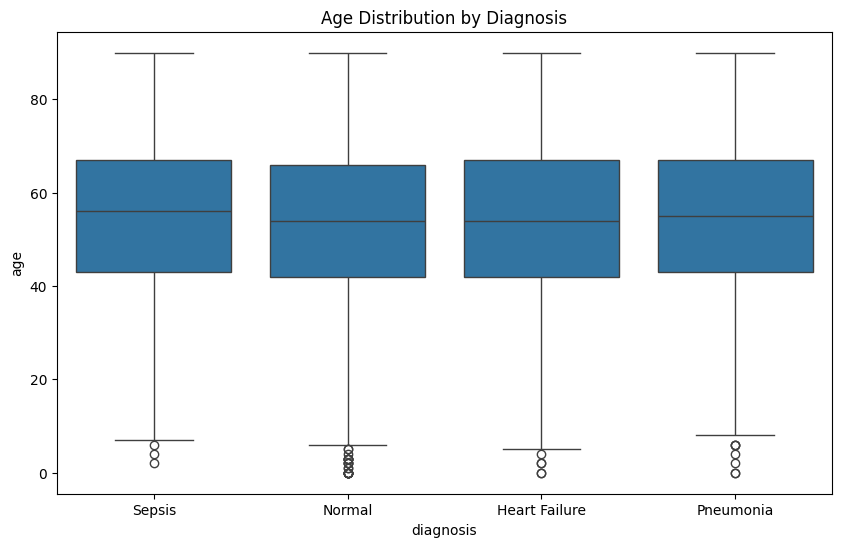

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='diagnosis', y='age', data=dataset)
plt.title("Age Distribution by Diagnosis")
plt.show()

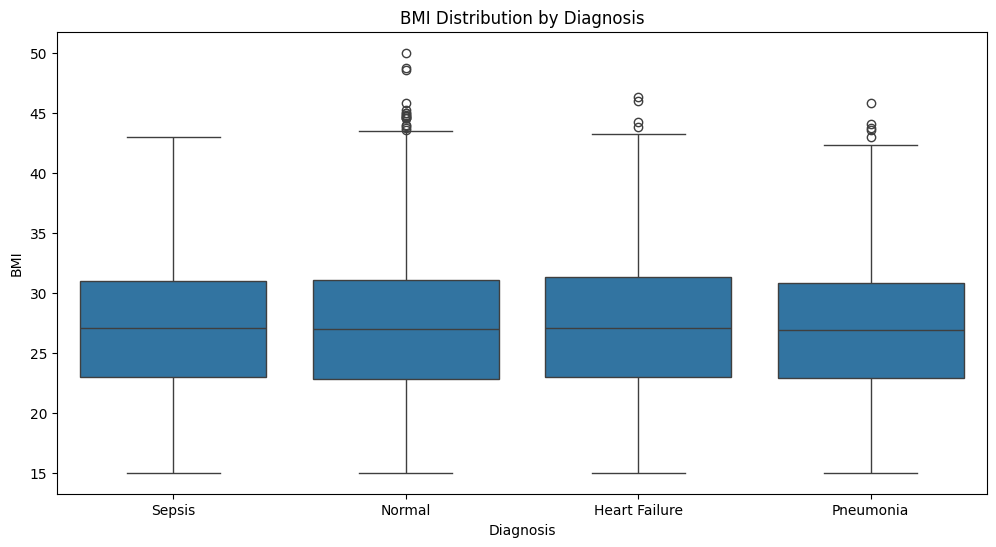

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(x='diagnosis', y='bmi', data=dataset)
plt.title("BMI Distribution by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("BMI")
plt.show()

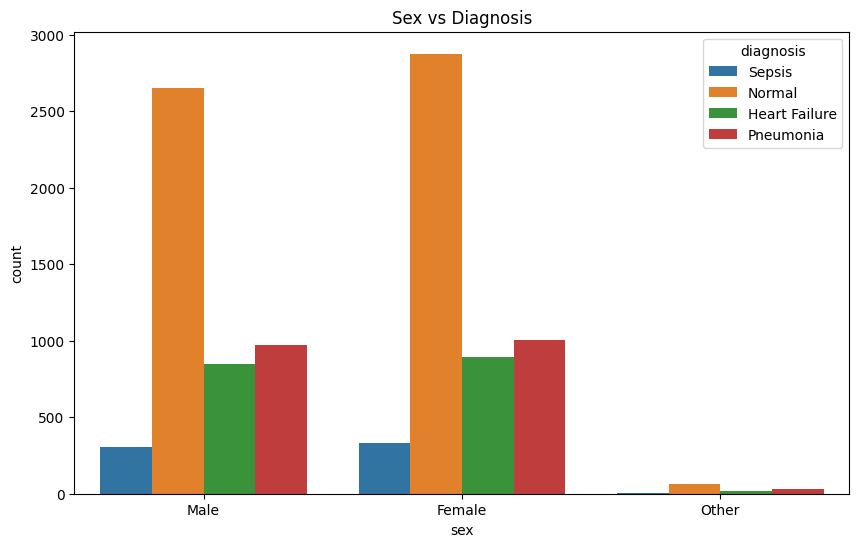

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(x='sex', hue='diagnosis', data=dataset)
plt.title("Sex vs Diagnosis")
plt.show()

Summary: In a Markdown cell, write 2-3 sentences summarizing key data characteristics that will inform your modeling approach (class imbalance, missing data patterns, feature relationships you observed)
The dataset consists of alot of normal diagnosis between men and women, but intrestingly, ahs similar numbhers to pneuomia and heart failure. The full dataset does not consist of any missing values, so no cleaning or data filling will be needed in this project. Age distribution seems to be consistent across all diagnosis, not signaling a specific age gorup happens to get a certain diagnosis over the other. Finally, BMI for normal diagnosis seems to have a lot mroe outliers of 50 + compared to the other dianogisies in this dataset.

### Step 3: 2-3 custom features

#### 1. Age Groups
- Calculation: I will make age into certain categories based off the age range
    - Child (0-17)
    - Young Adult (18-35)
    - Adult (36-55)
    - Senior (56-75)
    - Elderly (76+)
- Why is should help?: This would allow to further classify our data into categories and distinguish a specific age population is more likely to get a certain disaese than others. It would help create patterns for the disgnosis patterns.
- Domain Justifiucation: Age ranges are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.


In [36]:
age_edge_cases = [0, 17, 35, 55, 75, 120]  
age_labels = ['Child', 'Young Adult', 'Adult', 'Senior', 'Elderly']
dataset['agegroup'] = pd.cut(dataset['age'], bins=age_edge_cases, labels=age_labels)

#### 2. BMI Category
- Calculation: I will split off BMI into to the following catoegories
    - Underweight (< 18.5)
    - Normal (18.5-24.9)
    - Overweight (25-29.9)
    - obese (30+)
- Why it should help?: THis would help capture certain BMI ranges that could lead to certain diagnosis. With the same reasoning of Age groups, BMI ranges are often used in praticiaal settings and help show patterns of when certain diagnosis can happen if a person is in a certain BMI range
- Domain Jusitifation: are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.

In [37]:
bmi_edge_cases = [0, 18.5, 24.9, 29.9, 100] 
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
dataset['bmicategory'] = pd.cut(dataset['bmi'], bins=bmi_edge_cases, labels=bmi_labels)

In [39]:
#Data example with new categories
print(dataset[['age', 'agegroup', 'bmi', 'bmicategory']].head(10))

   age agegroup   bmi  bmicategory
0   63   Senior  24.1       Normal
1   52    Adult  20.8       Normal
2   66   Senior  30.0        Obese
3   82  Elderly  16.8  Underweight
4   50    Adult  25.4   Overweight
5   50    Adult  15.0  Underweight
6   83  Elderly  19.0       Normal
7   68   Senior  21.7       Normal
8   46    Adult  33.6        Obese
9   64   Senior  31.1        Obese


### Step 4: Prepare Data for modeling

In [ ]:
X = dataset.drop(columns=['diagnosis'])
y = dataset['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['age', 'bmi']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality,agegroup,bmicategory
7310,8311,-0.471702,Male,-0.014348,144.0,95.0,138.6,186.7,0.99,0,0,0,0,Adult,Overweight
7683,8684,1.573526,Male,-0.031529,118.0,89.0,100.0,134.5,0.97,0,0,0,0,Elderly,Overweight
648,1649,-0.244454,Male,1.480401,122.0,90.0,98.2,156.1,0.50,0,0,1,0,Adult,Obese
1986,2987,0.778160,Male,0.638531,118.0,62.0,108.8,169.4,1.05,0,1,0,0,Senior,Obese
5525,6526,-0.642138,Male,-0.117434,138.0,88.0,70.0,209.8,1.41,0,0,0,0,Adult,Overweight


#### Doumentation for step4: 
- Train/Test Splits
    - 80% Training, 20% Testing (normal range we used in class for data spliting)
    - Startified by Diagnosis feature as this the feature I want to make predictions and test on with proper proportions that this dataset presented in both sets.
- Missing Values
    - There were none to fix
- Feature Scaling
    - Age and BMI were scaled using the StandardScaler method as they were numeric features that can get large and influence model training. Standarizing and scaling them would allow for mor eproper data training and data handling with my models.

### Step 5: Implement first model (Random Forest)

In [50]:
X_train_numeric = pd.get_dummies(X_train_scaled, columns=['agegroup', 'bmicategory', 'sex'], drop_first=True)
X_test_numeric = pd.get_dummies(X_test_scaled, columns=['agegroup', 'bmicategory', 'sex'], drop_first=True)

X_test_numeric_groups = X_test_numeric.reindex(columns=X_train_numeric.columns, fill_value=0)

In [79]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,    
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

random_forest_model.fit(X_train_numeric, y_train)

random_forest_time = time.time() - start_time

y_pred = random_forest_model.predict(X_test_numeric)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy: ", accuracy)
print("F1-score: ", f1)
print("time:", random_forest_time)

Accuracy:  0.557
F1-score:  0.40223195293732034
time: 0.3330202102661133


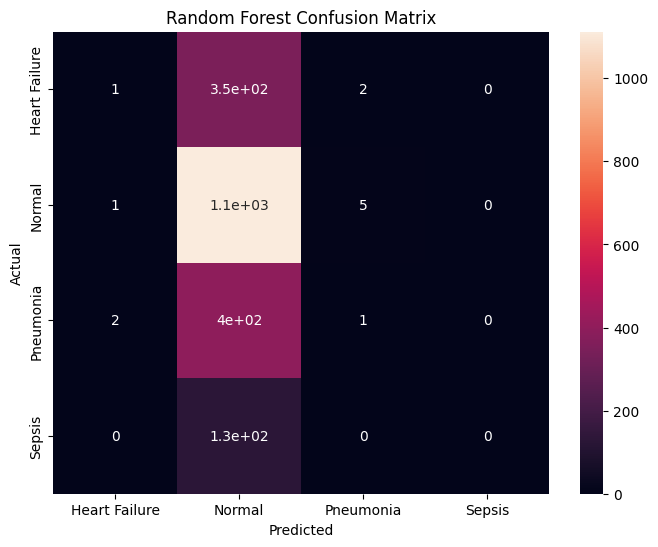

In [63]:
cm = confusion_matrix(y_test, y_pred, labels=random_forest_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, xticklabels=random_forest_model.classes_, yticklabels=random_forest_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Step 6: Implement second model (NN)

In [84]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)  
y_test = label_encoder.transform(y_test)

nn_model = keras.Sequential([
    keras.Input(shape=(X_train_numeric.shape[1],)), 
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])

nn_model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
start_time = time.time()

history = nn_model.fit(X_train_numeric, y_train, epochs=50, batch_size=32, validation_split=0.2)

nn_time = time.time() - start_time
nn_loss, accuarcy_nn = nn_model.evaluate(X_test_numeric, y_test)

y_pred = nn_model.predict(X_test_numeric)
y_pred = y_pred.argmax(axis=1)

f1_nn = f1_score(y_test, y_pred, average='weighted')
print("Neural Network Accuracy:", accuarcy_nn)
print("F1-score:", f1)
print("Time:", nn_time)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4929 - loss: 200.4109 - val_accuracy: 0.5131 - val_loss: 1.9706
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4293 - loss: 1.9025 - val_accuracy: 0.5075 - val_loss: 1.5473
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4628 - loss: 1.5994 - val_accuracy: 0.5194 - val_loss: 1.3415
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4343 - loss: 1.6708 - val_accuracy: 0.4906 - val_loss: 1.3715
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4662 - loss: 1.4840 - val_accuracy: 0.5525 - val_loss: 1.2909
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4799 - loss: 1.5653 - val_accuracy: 0.4169 - val_loss: 1.3968
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4591 - loss: 1.5832 - val_accuracy: 0.5519 - val_loss: 1.2446
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5003 - loss: 1.3552 - val_accuracy: 

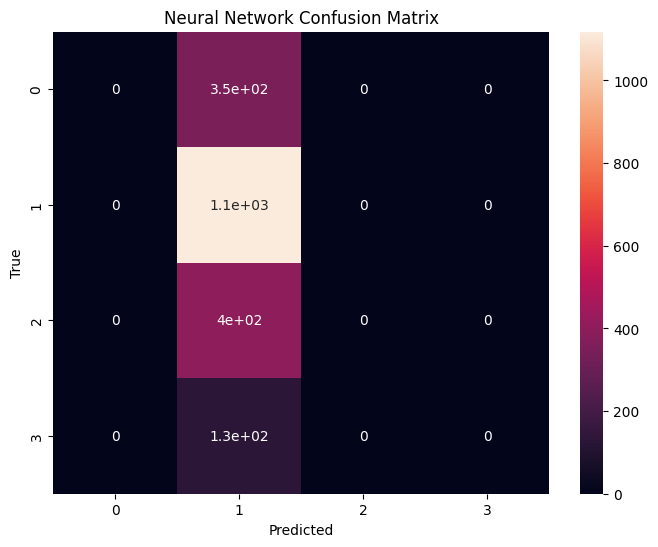

In [87]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Neural Network Confusion Matrix')
plt.show()

### Step 7: Comparing Models

In [90]:

random_forest_metrics = {
    "Model": "Random Forest",
    "Key Hyperparameters": "n_estimators=200, max_depth=None, random_state=42",
    "Accuracy": accuracy,
    "Weighted F1-score": f1,
    "Training Time (s)": random_forest_time,
}

nn_metrics = {
    "Model": "Neural Network",
    "Key Hyperparameters": "2 hidden layers [32,16], ReLU, softmax output",
    "Accuracy": accuarcy_nn,
    "Weighted F1-score": f1_nn,
    "Training Time (s)": nn_time,
}

comparison_df = pd.DataFrame([random_forest_metrics, nn_metrics])


comparison_df

,Model,Key Hyperparameters,Accuracy,Weighted F1-score,Training Time (s)
0,Random Forest,"n_estimators=200, max_depth=None, random_state=42",0.557,0.402232,0.333020
1,Neural Network,"2 hidden layers [32,16], ReLU, softmax output",0.559,0.400874,16.227932


The modlels both were close in performance metrics for both F1 score and accuarcy. Neural Networks did slightly better by .2% in accuarcy, while random forest did better by .014 in f1 score. It is safe to say the models both performed simiarly across this dataset. I would lean more into Neural networks as it has the higher accuarcy. I feel it would be easier to improve the model with neural networks by adjsuting the amount of layers, and size of layers for the dataset.

### Step 8: Reflection 

#### Feature engineering plans:
So far I have Age Groups and BMI categories. While I thought they could make an impact on determining if theres correlation to diagnosis with them, the model accuarcy and f1 scores did not reflect that, so adding more features would be imperitive to increase performance of the models. I can make Blood Pressure category that designates if someone has low, normal, or high blood pressure, which can have a correlation on to what diagnosis someone could have. Next, I can tap into the gluclose category and categorize that to see if someone has low, normal, or hiigh gluclose levels. Again, this could help determine what diagnosis someone can get. Lastly, we can combine the gluclose and bp metrics into its own catgory to determine if they both can lead to disagnosis of diseases for patients.

#### Model Optimization:
Right now, the model sits around 55% accuarcy and .40 f1 score. That will need some tweaking to be improved. Like I mentioned earlier, I want to go with the Neural Networks Aproach to help improve the accuacry and f1 score of that model to get a solid modle of determining someone can have a certain diagnosis. Adding these new feature would hope improve the model, but I am thinking add more hidden layers could also improve the eprformance of the model. Right now there are only three layers, and size of theose layers can be adjusted as well.

#### Feedback
Do you think increasing the size of these layers with these added features would help improve the model? 